In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [81]:
# Lista com os caminhos dos seus bancos de dados (ajuste se tiver mais)
DATABASES = [
    #"../data/dataset_artigo_balanceado.db"
    #"../data/dataset_artigo.db",
    #"../data/dataset_informacional.db",
    #"../data/dataset_social.db",
    #"../data/dataset.db",
    "../data/dataset_jornal_balanceado2.db",
    #"../data/dataset_livro.db",
    #"../data/dataset_literario_completo.db",
    #"../data/dataset_literario_balanceado.db",
    #"../data/dataset_literariro.db", # Coloque o nome exato que está na sua pasta
]

def carregar_dados(db_paths):
    dataframes = []
    
    for path in db_paths:
        if os.path.exists(path):
            try:
                # Conecta ao banco
                conn = sqlite3.connect(path)
                
                # Lê a tabela inteira para o Pandas
                df = pd.read_sql_query("SELECT * FROM texts", conn)
                
                # Adiciona uma coluna com o nome do arquivo para rastreio
                df['origem_db'] = os.path.basename(path)
                
                dataframes.append(df)
                conn.close()
                print(f"[OK] {os.path.basename(path)}: {len(df)} textos carregados.")
            except Exception as e:
                print(f"[ERRO] Falha ao ler {path}: {e}")
        else:
            print(f"[AVISO] Ficheiro não encontrado: {path}")
            
    # Une todos os dataframes num só (Empilhamento)
    if dataframes:
        df_completo = pd.concat(dataframes, ignore_index=True)
        print(f"\n[SUCESSO] Dataset unificado criado com {len(df_completo)} textos no total!")
        return df_completo
    else:
        return pd.DataFrame()

# Executa a função
df = carregar_dados(DATABASES)

# Mostra as primeiras 5 linhas para confirmar que deu certo
display(df.head())

[OK] dataset_jornal_balanceado2.db: 6453 textos carregados.

[SUCESSO] Dataset unificado criado com 6453 textos no total!


,text_id,content,label,broad_area,specific_theme,char_count,word_count,size_category,creation_date,source_url,source_name,content_hash,origem_db
0,fb6e8b8e-3841-4b2d-8c8b-f28fb4349a0c,O que vai ser notícia em 2018 na área de astro...,0,NaN,None,5299,903,Longo,2017,http://g1.globo.com/ciencia-e-saude/blog/cassi...,g1.globo.com,dad4b8943a880802fd248e0ffaec9e13,dataset_jornal_balanceado2.db
1,62a464c0-49e9-4c80-881b-79b2deab327d,Ou o estranho caso de um super-olfato que pode...,0,NaN,None,4015,635,Médio-Longo,2016,http://g1.globo.com/ciencia-e-saude/blog/espiral/,g1.globo.com,d5cf6d0a1c3009528bf92f96e849dc97,dataset_jornal_balanceado2.db
2,99d4a07f-6c43-412c-aead-372ee800a530,Transmitido ao vivo em 21/08/2017 18h27\nEclip...,0,NaN,None,158,24,Curto,2017,http://g1.globo.com:80/ciencia-e-saude/ao-vivo...,g1.globo.com:80,221b400d59cc55b6d4a7605433e08477,dataset_jornal_balanceado2.db
3,06b26831-27e2-4f3c-a51f-341b9a2fca2e,Existe um grande debate entre os neurocientist...,0,NaN,None,3427,524,Médio-Longo,2016,http://g1.globo.com:80/ciencia-e-saude/blog/es...,g1.globo.com:80,7f0b24130c28a6f30896fe999ca82d50,dataset_jornal_balanceado2.db
4,5758b0ba-232d-4d02-b48a-cc5829264163,"RESUMO DO POST:\nNeste texto, Alysson Muotri a...",0,NaN,None,5855,858,Longo,2017,http://g1.globo.com/ciencia-e-saude/blog/espir...,g1.globo.com,52686e5f17beb857f78819f27ed6e3f9,dataset_jornal_balanceado2.db


C:\Users\Victor\AppData\Local\Temp\ipykernel_11128\3325772977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='broad_area', order=ordem, palette='viridis')


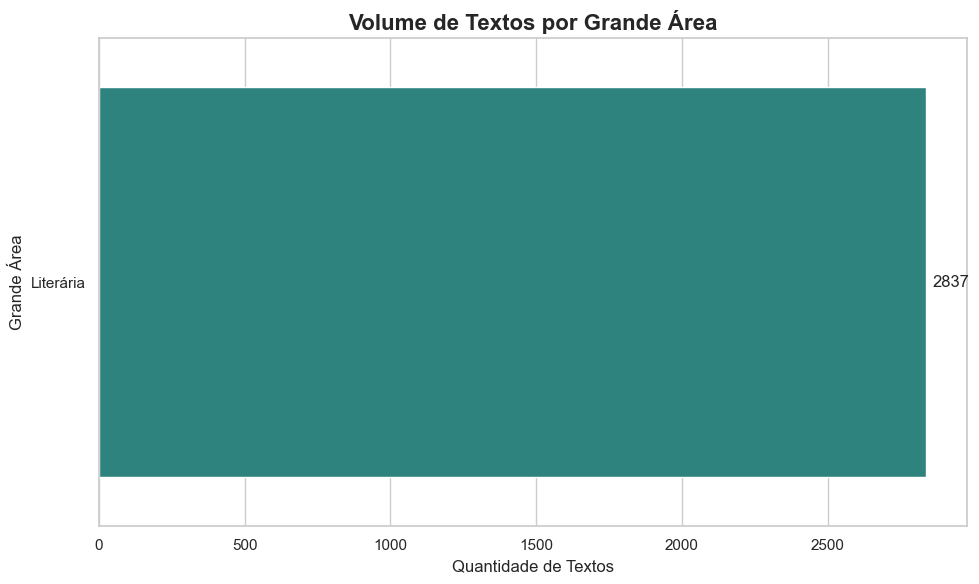

In [74]:
plt.figure(figsize=(10, 6))

# Ordenar por quantidade decrescente
ordem = df['broad_area'].value_counts().index
ax = sns.countplot(data=df, y='broad_area', order=ordem, palette='viridis')

plt.title('Volume de Textos por Grande Área', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Textos')
plt.ylabel('Grande Área')

# Adiciona o número exato à frente de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

C:\Users\Victor\AppData\Local\Temp\ipykernel_11128\3835821549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='size_category', order=ordem_tamanho, palette='magma')


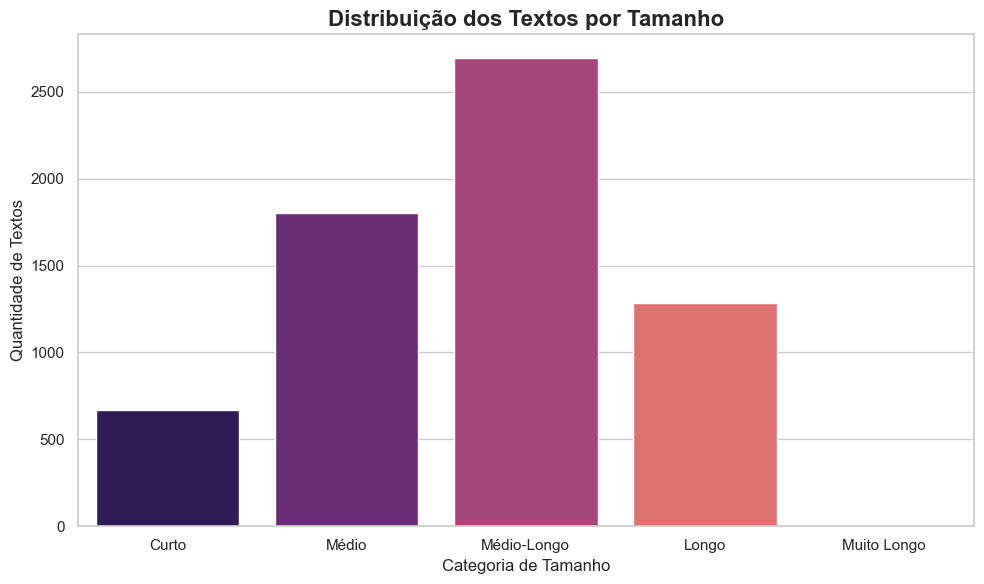

In [82]:
plt.figure(figsize=(10, 6))

# Define a ordem lógica das suas categorias
ordem_tamanho = ["Curto", "Médio", "Médio-Longo", "Longo", "Muito Longo"]

ax = sns.countplot(data=df, x='size_category', order=ordem_tamanho, palette='magma')

plt.title('Distribuição dos Textos por Tamanho', fontsize=16, fontweight='bold')
plt.xlabel('Categoria de Tamanho')
plt.ylabel('Quantidade de Textos')

plt.tight_layout()
plt.show()

C:\Users\Victor\AppData\Local\Temp\ipykernel_11128\161980344.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_temas.values, y=top_temas.index, palette='rocket')


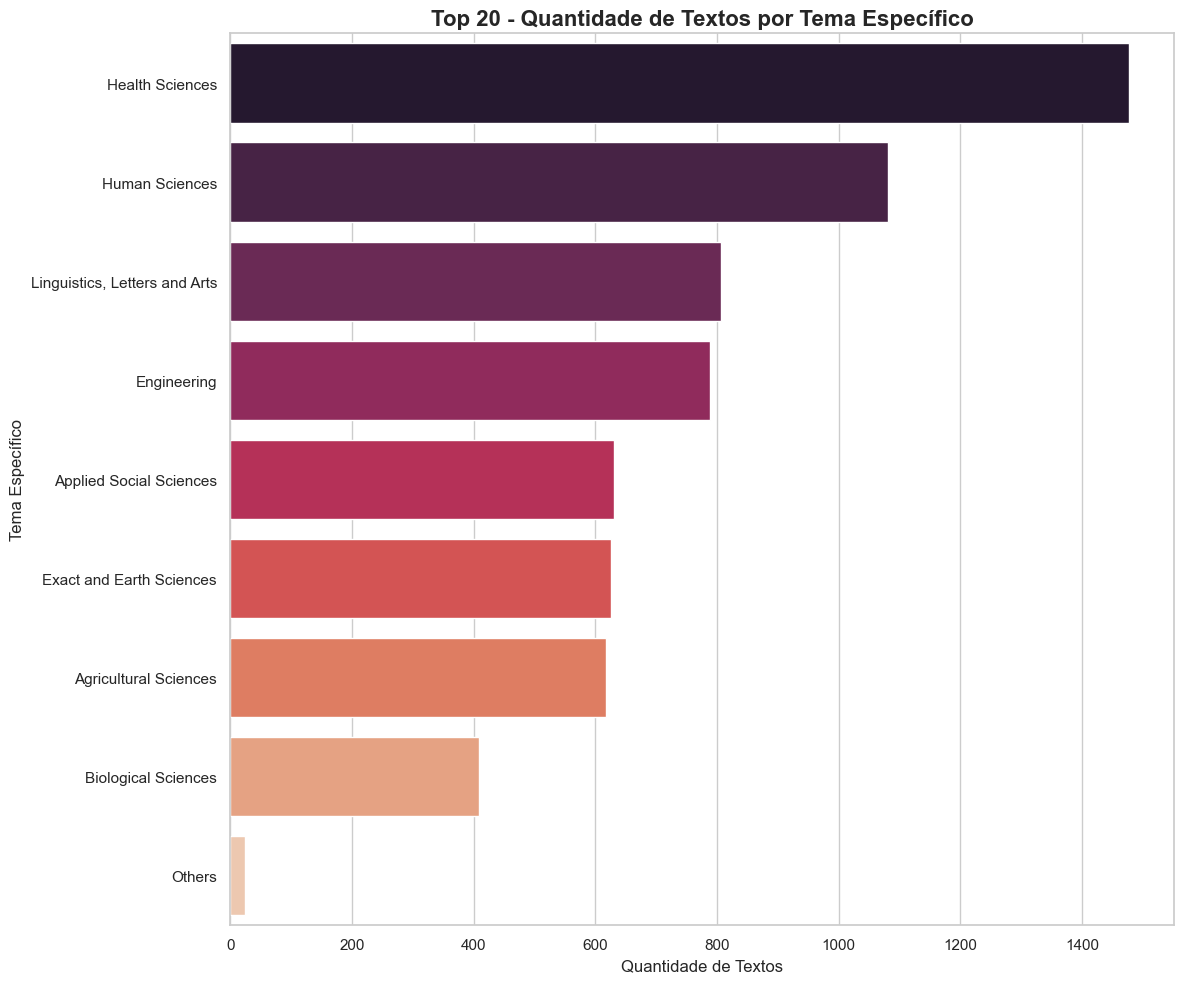

In [59]:
plt.figure(figsize=(12, 10))

# Pega apenas os 20 temas mais frequentes
top_temas = df['specific_theme'].value_counts().nlargest(20)

ax = sns.barplot(x=top_temas.values, y=top_temas.index, palette='rocket')

plt.title('Top 20 - Quantidade de Textos por Tema Específico', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Textos')
plt.ylabel('Tema Específico')

plt.tight_layout()
plt.show()